In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
# Load the Sleep and Lifestyle study data
data = pd.read_csv("./data/Sleep_health_and_lifestyle_dataset_2.csv")
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Text(0.5, 1.0, 'Stress Level Distribution')

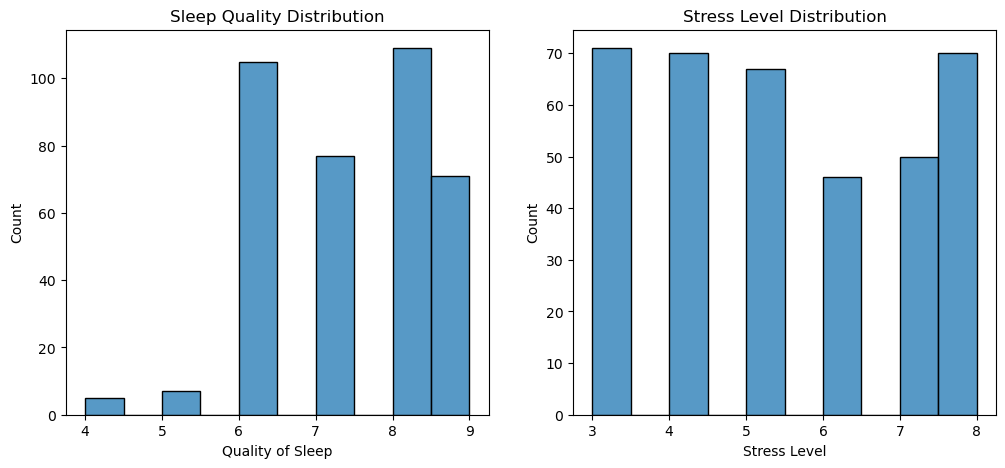

In [3]:
# Visualize the distributions of sleep quality and stress levels
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(data=data, x="Quality of Sleep", ax=ax[0])
ax[0].set_title("Sleep Quality Distribution")
sns.histplot(data=data, x="Stress Level", ax=ax[1])
ax[1].set_title("Stress Level Distribution")

Text(0.5, 1.0, 'Heart Rate vs. Sleep Quality')

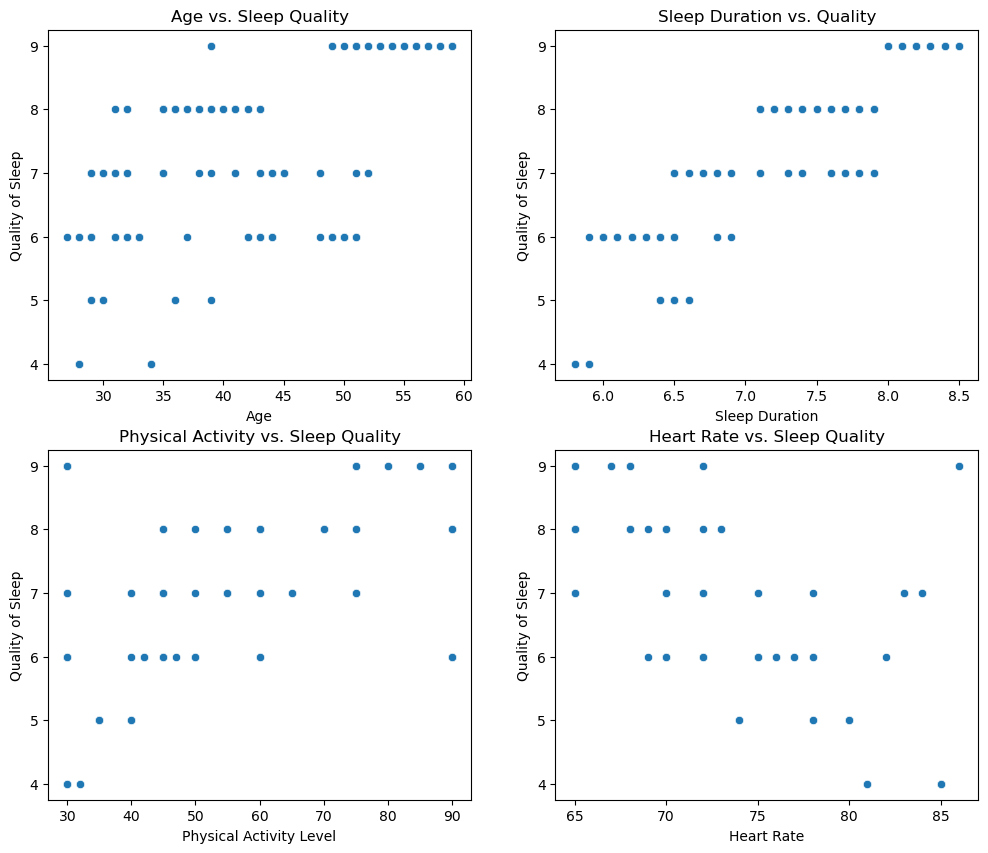

In [4]:
# Visualize realtionships between sleep quality and numerical variables
fig, ax = plt.subplots(2, 2, figsize = (12,10))
sns.scatterplot(data=data, x="Age", y="Quality of Sleep", ax=ax[0,0])
ax[0,0].set_title("Age vs. Sleep Quality")
sns.scatterplot(data=data, x="Sleep Duration", y="Quality of Sleep", ax=ax[0,1])
ax[0,1].set_title("Sleep Duration vs. Quality")
sns.scatterplot(data=data, x="Physical Activity Level", y="Quality of Sleep", ax=ax[1,0])
ax[1,0].set_title("Physical Activity vs. Sleep Quality")
sns.scatterplot(data=data, x="Heart Rate", y="Quality of Sleep", ax=ax[1,1])
ax[1,1].set_title("Heart Rate vs. Sleep Quality")

Text(0.5, 1.0, 'Heart Rate vs. Stress Level')

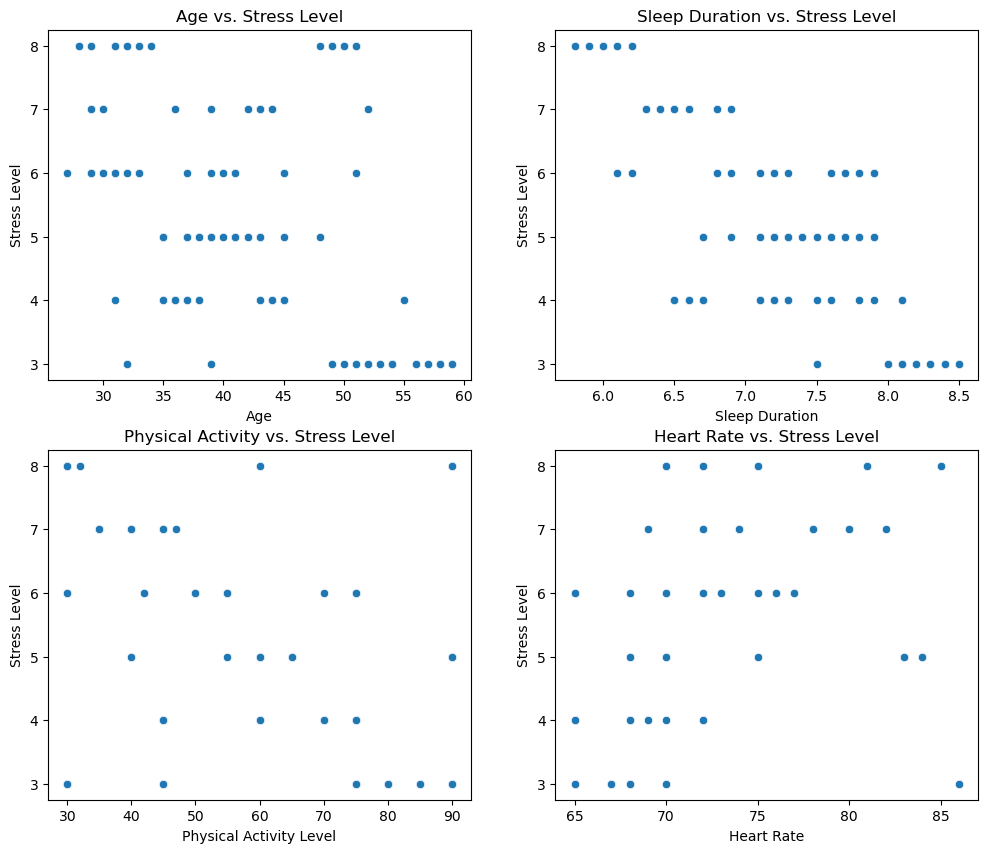

In [5]:
# Visualize realtionships between stress level and numerical variables
fig, ax = plt.subplots(2, 2, figsize = (12,10))
sns.scatterplot(data=data, x="Age", y="Stress Level", ax=ax[0,0])
ax[0,0].set_title("Age vs. Stress Level")
sns.scatterplot(data=data, x="Sleep Duration", y="Stress Level", ax=ax[0,1])
ax[0,1].set_title("Sleep Duration vs. Stress Level")
sns.scatterplot(data=data, x="Physical Activity Level", y="Stress Level", ax=ax[1,0])
ax[1,0].set_title("Physical Activity vs. Stress Level")
sns.scatterplot(data=data, x="Heart Rate", y="Stress Level", ax=ax[1,1])
ax[1,1].set_title("Heart Rate vs. Stress Level")

Text(0.5, 1.0, 'Distributions of Sleep Quality for each BMI category')

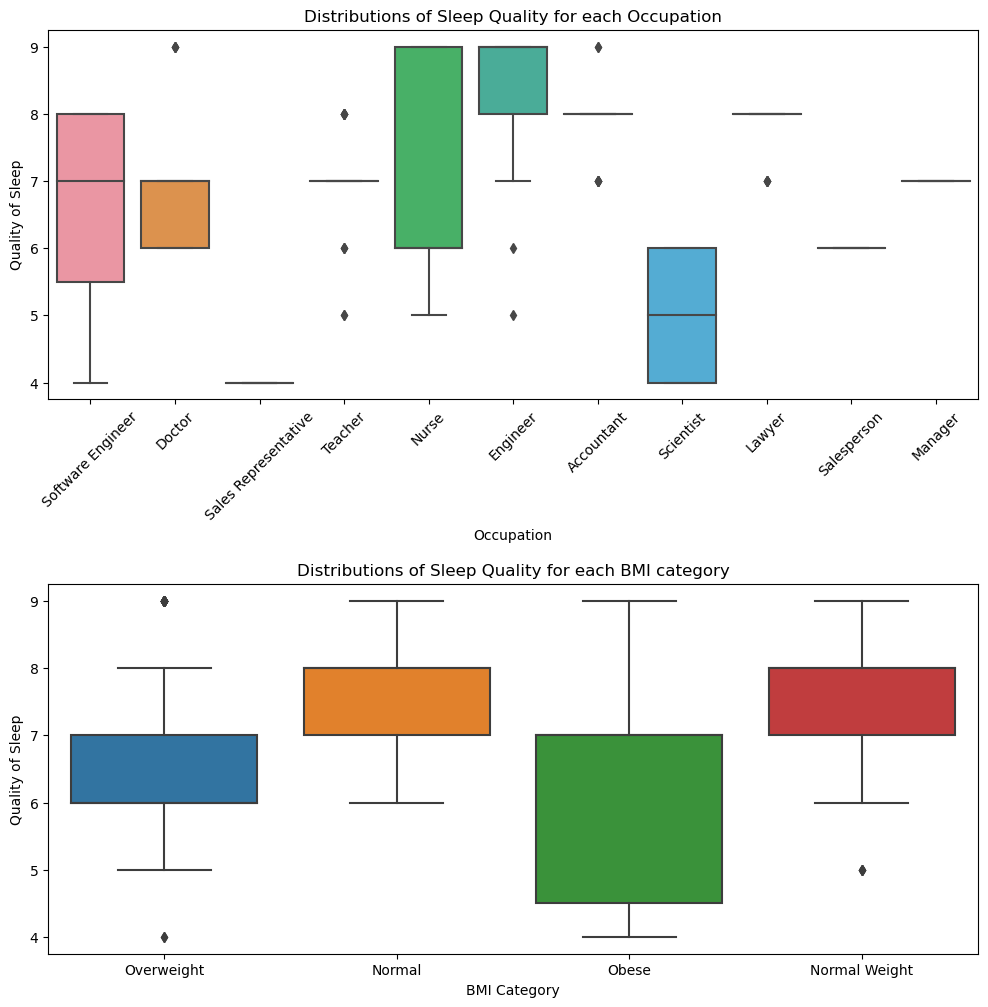

In [6]:
# Use boxplots to visualize distributions of sleep quality for each category in categorical variables
fig, ax = plt.subplots(2, 1, figsize=(12,12), gridspec_kw={'hspace': 0.5,'wspace': 0.5})
sns.boxplot(data=data, x="Occupation", y="Quality of Sleep", ax=ax[0])
ax[0].set_title("Distributions of Sleep Quality for each Occupation")
ax[0].tick_params(axis='x', labelrotation=45)
sns.boxplot(data=data, x="BMI Category", y="Quality of Sleep", ax=ax[1])
ax[1].set_title("Distributions of Sleep Quality for each BMI category")

Text(0.5, 1.0, 'Distributions of Stress Level for each BMI category')

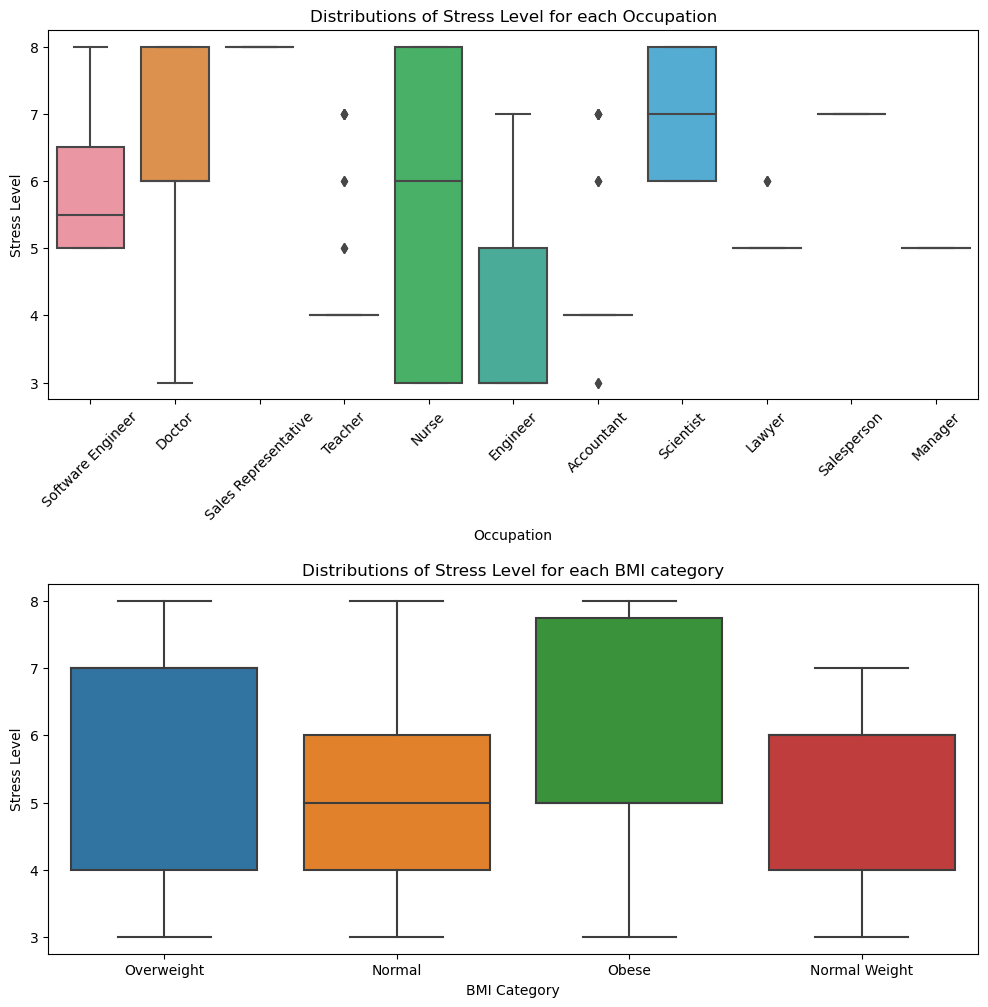

In [7]:
# Use boxplots to visualize distributions of stress level for each category in categorical variables
fig, ax = plt.subplots(2, 1, figsize=(12,12), gridspec_kw={'hspace': 0.5,'wspace': 0.5})
sns.boxplot(data=data, x="Occupation", y="Stress Level", ax=ax[0])
ax[0].set_title("Distributions of Stress Level for each Occupation")
ax[0].tick_params(axis='x', labelrotation=45)
sns.boxplot(data=data, x="BMI Category", y="Stress Level", ax=ax[1])
ax[1].set_title("Distributions of Stress Level for each BMI category")

In [8]:
# Split blood pressure into the systolic and diastolic blood pressures
data[["Systolic Blood Pressure", "Diastolic Blood Pressure"]] = data["Blood Pressure"].str.split('/', expand=True)
data[["Systolic Blood Pressure", "Diastolic Blood Pressure"]] = data[["Systolic Blood Pressure", "Diastolic Blood Pressure"]].astype(int)
data = data.drop(columns=["Blood Pressure"])

# Define different column types and separate the data into features and targets
cat_columns = ["Occupation", "BMI Category", "Sleep Disorder", "Gender"]
num_columns = ["Age", "Sleep Duration", "Physical Activity Level", "Heart Rate", "Daily Steps", "Systolic Blood Pressure", "Diastolic Blood Pressure"]
features = cat_columns + num_columns

X, sleep_quality, stress = data[features], data["Quality of Sleep"], data["Stress Level"]

In [9]:
# Convert stress to be a binary variable for binary classification (0 represents low stress, 1 represents high stress)
stress = np.where(stress > 5, 1, 0)

In [10]:
# Preform the train-test split
X_train, X_test, stress_train, stress_test, quality_train, quality_test = train_test_split(X, stress, sleep_quality, test_size = 0.1, random_state = 6)

In [11]:
# Define preprocessing for each feature
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="if_binary", handle_unknown = "ignore")
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_columns),
        ('cat', categorical_transformer, cat_columns),
    ]
)
cat_preprocessor = ColumnTransformer(
    transformers = [('cat', categorical_transformer, cat_columns)]
)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
X_train_cat_transformed = cat_preprocessor.fit_transform(X_train)
X_test_cat_transformed = cat_preprocessor.transform(X_test)

In [12]:
# Tune the k value of the kNN classifier using 5-fold cross validation
knn_param_grid = {
    'n_neighbors': [1, 2, 3, 4, 5, 10, 20]
}
search_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5)
search_knn.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 10, 20]})

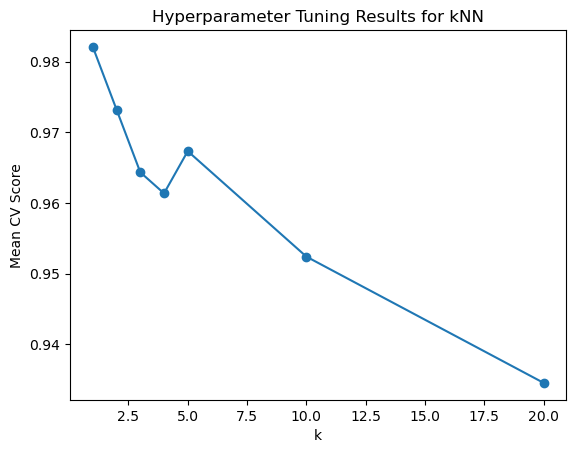

In [13]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_knn.cv_results_)
plt.figure()
plt.plot(results_df['param_n_neighbors'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for kNN")
plt.xlabel("k")
plt.ylabel("Mean CV Score")
plt.show()

In [14]:
# Fit a kNN classifier with the best value of k
knn_classifier = KNeighborsClassifier(n_neighbors = search_knn.best_params_['n_neighbors'])
start_time = time.time()
knn_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

Training took 0.0006 seconds


In [15]:
# Make predictions on the test set and report the prediction accuracy of the kNN model
start_time = time.time()
stress_pred_knn = knn_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(knn_classifier.score(X_test_transformed, stress_test))
knn_accuracy = 1 - (np.sum(np.where(stress_pred_knn != stress_test, 1, 0)) / np.size(stress_test))
print(knn_accuracy)

Testing took 0.0010 seconds
0.9736842105263158
0.9736842105263158


In [16]:
# Fit and test a decision tree classifier with a tuned max_depth
dt_param_grid = {
    'max_depth': [1, 2, 3, 5, 7, 10, None]
}
search_dt = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5)
search_dt.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 3, 5, 7, 10, None]})

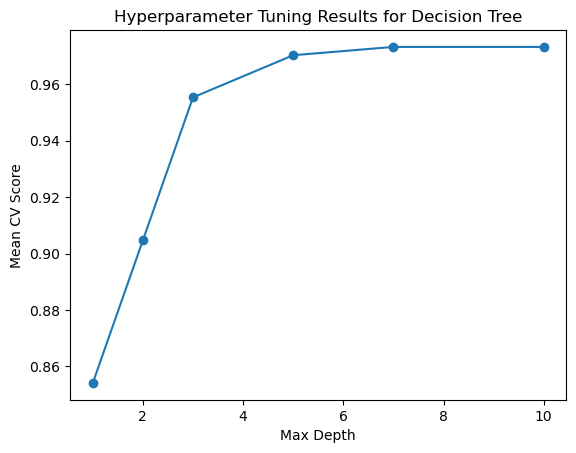

In [17]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_dt.cv_results_)
plt.figure()
plt.plot(results_df['param_max_depth'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Decision Tree")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Score")
plt.show()

In [18]:
dt_classifier = DecisionTreeClassifier(max_depth = search_dt.best_params_['max_depth'])
start_time = time.time()
dt_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
stress_pred_dt = dt_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(dt_classifier.score(X_test_transformed, stress_test))
dt_accuracy = 1 - (np.sum(np.where(stress_pred_dt != stress_test, 1, 0)) / np.size(stress_test))
print(dt_accuracy)

Training took 0.0010 seconds
Testing took 0.0001 seconds
0.9473684210526315
0.9473684210526316


In [19]:
# Fit and test a SVM classifier with a tuned value of C and kernel chosen from linear, polynomial, and gaussian RBF using 5-fold cross validation
svm_param_grid = {
    'C': [0.1, 1, 10, 50, 100, 500, 1000],
    'kernel': ['linear', 'poly', 'rbf']
}
search_svm = GridSearchCV(SVC(), svm_param_grid, cv=5)
search_svm.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 50, 100, 500, 1000],
                         'kernel': ['linear', 'poly', 'rbf']})

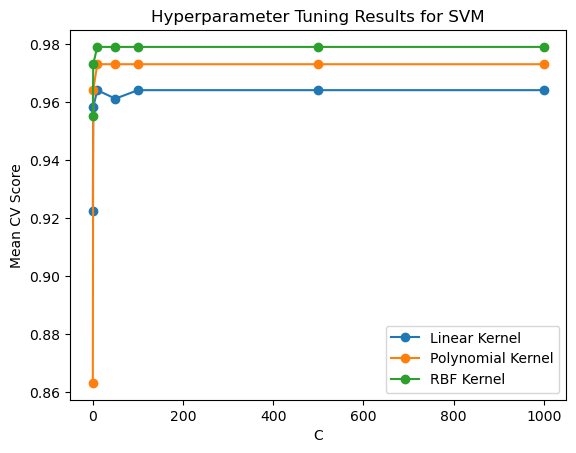

In [20]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_svm.cv_results_)
plt.figure()
plt.plot(results_df.loc[results_df['param_kernel'] == 'linear', 'param_C'], results_df.loc[results_df['param_kernel'] == 'linear', 'mean_test_score'], marker='o', label="Linear Kernel")
plt.plot(results_df.loc[results_df['param_kernel'] == 'poly', 'param_C'], results_df.loc[results_df['param_kernel'] == 'poly', 'mean_test_score'], marker='o', label="Polynomial Kernel")
plt.plot(results_df.loc[results_df['param_kernel'] == 'rbf', 'param_C'], results_df.loc[results_df['param_kernel'] == 'rbf', 'mean_test_score'], marker='o', label="RBF Kernel")
plt.title("Hyperparameter Tuning Results for SVM")
plt.xlabel("C")
plt.ylabel("Mean CV Score")
plt.legend()
plt.show()

In [21]:
svm_classifier = SVC(C = search_svm.best_params_['C'], kernel = search_svm.best_params_['kernel'])
start_time = time.time()
svm_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
stress_pred_svm = svm_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(svm_classifier.score(X_test_transformed, stress_test))
svm_accuracy = 1 - (np.sum(np.where(stress_pred_svm != stress_test, 1, 0)) / np.size(stress_test))
print(svm_accuracy)

Training took 0.0011 seconds
Testing took 0.0002 seconds
1.0
1.0


In [22]:
# Fit and test a random forest classifier with a tuned max depth using 5-fold cross validation
# Max depth choices are higher for random forest than for a single decision tree to take advantage of lower bias in bagging
rf_param_grid = {
    'max_depth': [3, 5, 7, 10, 13, None]
}
search_rf = GridSearchCV(RandomForestClassifier(n_estimators = 200, bootstrap = True), rf_param_grid, cv=5)
search_rf.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_estimators=200),
             param_grid={'max_depth': [3, 5, 7, 10, 13, None]})

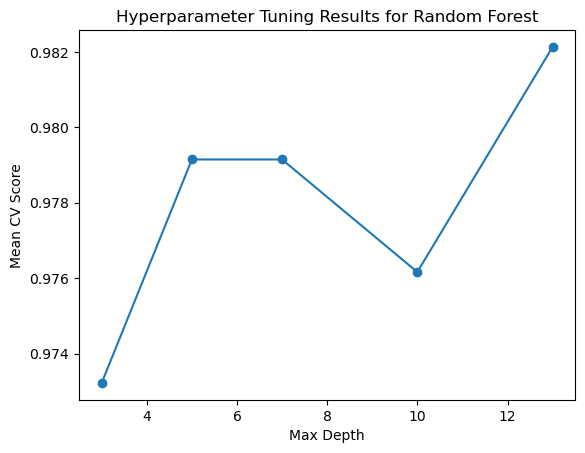

In [23]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_rf.cv_results_)
plt.figure()
plt.plot(results_df['param_max_depth'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Random Forest")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Score")
plt.show()

In [24]:
rf_classifier = RandomForestClassifier(max_depth = search_rf.best_params_['max_depth'], n_estimators = 200, bootstrap = True)
start_time = time.time()
rf_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
stress_pred_rf = rf_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(rf_classifier.score(X_test_transformed, stress_test))
rf_accuracy = 1 - (np.sum(np.where(stress_pred_rf != stress_test, 1, 0)) / np.size(stress_test))
print(rf_accuracy)

Training took 0.0721 seconds
Testing took 0.0028 seconds
0.9736842105263158
0.9736842105263158


In [25]:
# Fit and test a naive Bayes classifier with a tuned additive smoothing parameter using 5-fold cross validation
nb_param_grid = {
    'alpha': [1, 2, 3]
}
search_nb = GridSearchCV(CategoricalNB(min_categories=2), nb_param_grid, cv=5)
search_nb.fit(X_train_cat_transformed.toarray(), stress_train)

GridSearchCV(cv=5, estimator=CategoricalNB(min_categories=2),
             param_grid={'alpha': [1, 2, 3]})

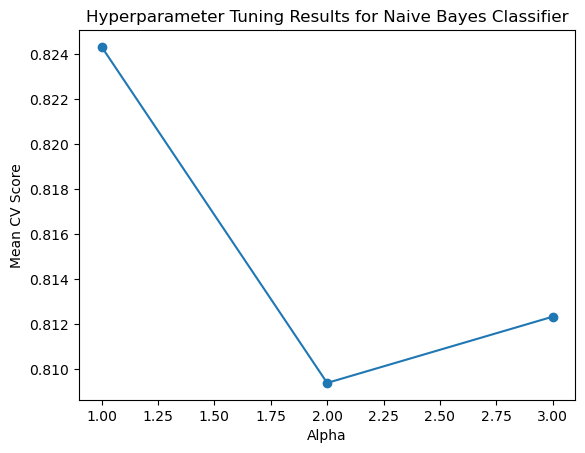

In [26]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_nb.cv_results_)
plt.figure()
plt.plot(results_df['param_alpha'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Naive Bayes Classifier")
plt.xlabel("Alpha")
plt.ylabel("Mean CV Score")
plt.show()

In [27]:
nb_classifier = CategoricalNB(min_categories = 2, alpha = search_nb.best_params_['alpha'])
start_time = time.time()
nb_classifier.fit(X_train_cat_transformed.toarray(), stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
stress_pred_nb = nb_classifier.predict(X_test_cat_transformed.toarray())
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(nb_classifier.score(X_test_cat_transformed.toarray(), stress_test))
nb_accuracy = 1 - (np.sum(np.where(stress_pred_nb != stress_test, 1, 0)) / np.size(stress_test))
print(nb_accuracy)

Training took 0.0018 seconds
Testing took 0.0002 seconds
0.868421052631579
0.868421052631579


In [28]:
# Fit and test an artificial neural network with a tuned number of hidden layer nodes, and choices of activation function and max iterations made using 5-fold cross validation
# Note: This code cell takes a long time to run
ann_param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (20,), (50,), (100,), (150,)],
    'max_iter': [2000, 5000, 10000, 20000],
    'activation': ['logistic', 'tanh', 'relu']
}
search_ann = GridSearchCV(MLPClassifier(), ann_param_grid, cv=5)
search_ann.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=MLPClassifier(),
             param_grid={'activation': ['logistic', 'tanh', 'relu'],
                         'hidden_layer_sizes': [(5,), (10,), (20,), (50,),
                                                (100,), (150,)],
                         'max_iter': [2000, 5000, 10000, 20000]})

<Figure size 640x480 with 0 Axes>

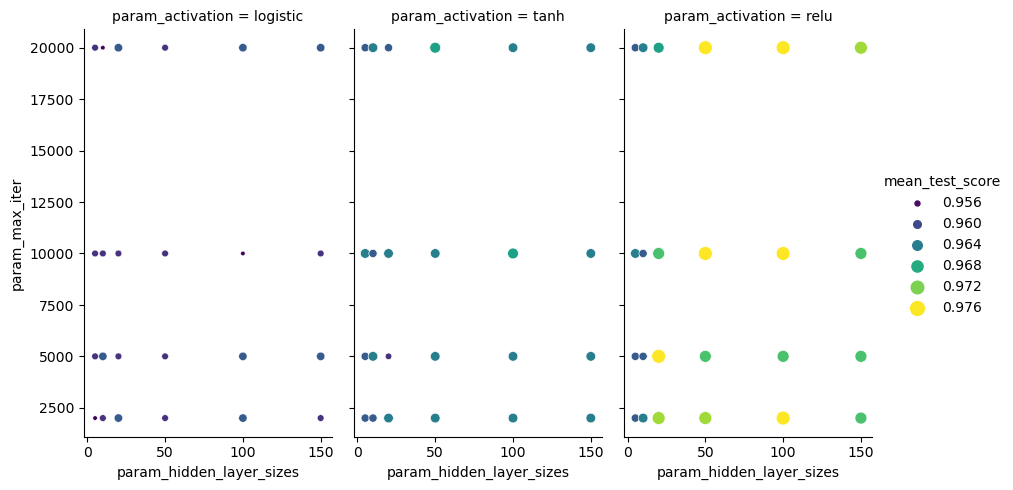

In [29]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_ann.cv_results_)
results_df['param_hidden_layer_sizes'] = results_df['param_hidden_layer_sizes'].str[0].astype(int)
plt.figure()
sns.relplot(data=results_df, x="param_hidden_layer_sizes", y="param_max_iter", hue="mean_test_score", col="param_activation", palette="viridis", kind="scatter", size="mean_test_score", sizes=(10,100), aspect=0.6)
plt.show()

In [30]:
ann_classifier = MLPClassifier(hidden_layer_sizes = search_ann.best_params_['hidden_layer_sizes'], max_iter = search_ann.best_params_['max_iter'], activation = search_ann.best_params_['activation'])
start_time = time.time()
ann_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
stress_pred_ann = ann_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(ann_classifier.score(X_test_transformed, stress_test))
ann_accuracy = 1 - (np.sum(np.where(stress_pred_ann != stress_test, 1, 0)) / np.size(stress_test))
print(ann_accuracy)

Training took 0.0763 seconds
Testing took 0.0001 seconds
1.0
1.0


In [31]:
# Fit a kNN model for multi-class classification using a tuned k value
search_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5)
search_knn.fit(X_train_transformed, quality_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 10, 20]})

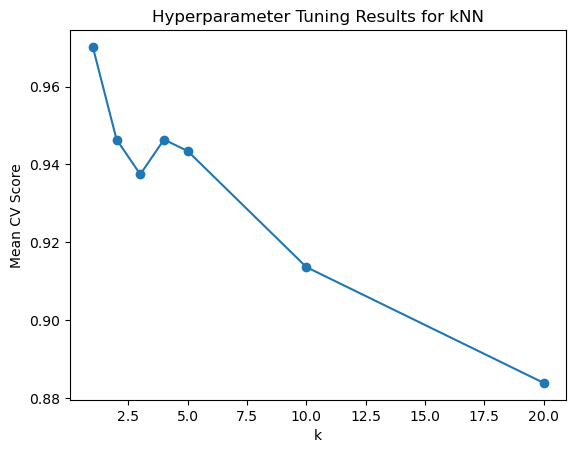

In [32]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_knn.cv_results_)
plt.figure()
plt.plot(results_df['param_n_neighbors'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for kNN")
plt.xlabel("k")
plt.ylabel("Mean CV Score")
plt.show()

In [33]:
knn_classifier_multi = KNeighborsClassifier(n_neighbors = search_knn.best_params_['n_neighbors'])
start_time = time.time()
knn_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
quality_pred_knn = knn_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(knn_classifier_multi.score(X_test_transformed, quality_test))
knn_accuracy_multi = 1 - (np.sum(np.where(quality_pred_knn != quality_test, 1, 0)) / np.size(quality_test))
print(knn_accuracy_multi)

Training took 0.0004 seconds
Testing took 0.0012 seconds
0.9736842105263158
0.9736842105263158


In [34]:
# Fit a decision tree model for multi-class classification using a tuned max depth
search_dt = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5)
search_dt.fit(X_train_transformed, quality_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 3, 5, 7, 10, None]})

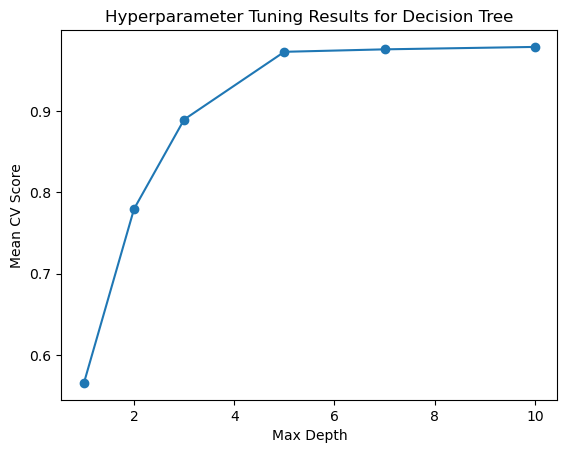

In [35]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_dt.cv_results_)
plt.figure()
plt.plot(results_df['param_max_depth'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Decision Tree")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Score")
plt.show()

In [36]:
dt_classifier_multi = DecisionTreeClassifier(max_depth = search_dt.best_params_['max_depth'])
start_time = time.time()
dt_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
quality_pred_dt = dt_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(dt_classifier_multi.score(X_test_transformed, quality_test))
dt_accuracy_multi = 1 - (np.sum(np.where(quality_pred_dt != quality_test, 1, 0)) / np.size(quality_test))
print(dt_accuracy_multi)

Training took 0.0009 seconds
Testing took 0.0002 seconds
0.9473684210526315
0.9473684210526316


In [37]:
# Fit a random forest classifier for multi-class classification using a tuned max depth
search_rf = GridSearchCV(RandomForestClassifier(), rf_param_grid, cv=5)
search_rf.fit(X_train_transformed, quality_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 7, 10, 13, None]})

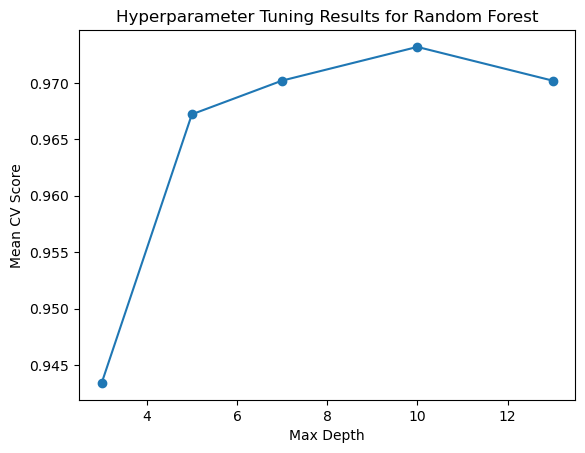

In [38]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_rf.cv_results_)
plt.figure()
plt.plot(results_df['param_max_depth'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Random Forest")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Score")
plt.show()

In [39]:
rf_classifier_multi = RandomForestClassifier(max_depth = search_rf.best_params_['max_depth'])
start_time = time.time()
rf_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
quality_pred_rf = rf_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(rf_classifier_multi.score(X_test_transformed, quality_test))
rf_accuracy_multi = 1 - (np.sum(np.where(quality_pred_rf != quality_test, 1, 0)) / np.size(quality_test))
print(rf_accuracy_multi)

Training took 0.0385 seconds
Testing took 0.0015 seconds
0.9736842105263158
0.9736842105263158


In [40]:
# Fit a svm classifier for multi-class classification using a tuned value of C and a kernel selected through 5-fold cross validation
search_svm = GridSearchCV(SVC(), svm_param_grid, cv=5)
search_svm.fit(X_train_transformed, quality_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 50, 100, 500, 1000],
                         'kernel': ['linear', 'poly', 'rbf']})

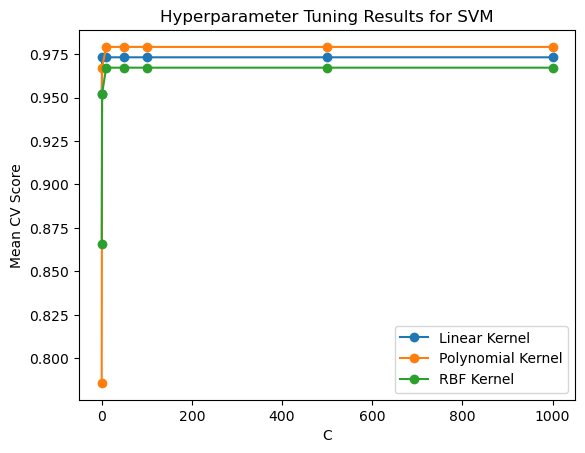

In [41]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_svm.cv_results_)
plt.figure()
plt.plot(results_df.loc[results_df['param_kernel'] == 'linear', 'param_C'], results_df.loc[results_df['param_kernel'] == 'linear', 'mean_test_score'], marker='o', label="Linear Kernel")
plt.plot(results_df.loc[results_df['param_kernel'] == 'poly', 'param_C'], results_df.loc[results_df['param_kernel'] == 'poly', 'mean_test_score'], marker='o', label="Polynomial Kernel")
plt.plot(results_df.loc[results_df['param_kernel'] == 'rbf', 'param_C'], results_df.loc[results_df['param_kernel'] == 'rbf', 'mean_test_score'], marker='o', label="RBF Kernel")
plt.title("Hyperparameter Tuning Results for SVM")
plt.xlabel("C")
plt.ylabel("Mean CV Score")
plt.legend()
plt.show()

In [42]:
svm_classifier_multi = SVC(C = search_svm.best_params_['C'], kernel = search_svm.best_params_['kernel'])
start_time = time.time()
svm_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
quality_pred_svm = svm_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(svm_classifier_multi.score(X_test_transformed, quality_test))
svm_accuracy_multi = 1 - (np.sum(np.where(quality_pred_svm != quality_test, 1, 0)) / np.size(quality_test))
print(svm_accuracy_multi)

Training took 0.0013 seconds
Testing took 0.0001 seconds
0.9736842105263158
0.9736842105263158


In [43]:
# Fit a naive Bayes classifier for multi-class classification with a tuned alpha parameter
search_nb = GridSearchCV(CategoricalNB(min_categories=2), nb_param_grid, cv=5)
search_nb.fit(X_train_cat_transformed.toarray(), quality_train)

GridSearchCV(cv=5, estimator=CategoricalNB(min_categories=2),
             param_grid={'alpha': [1, 2, 3]})

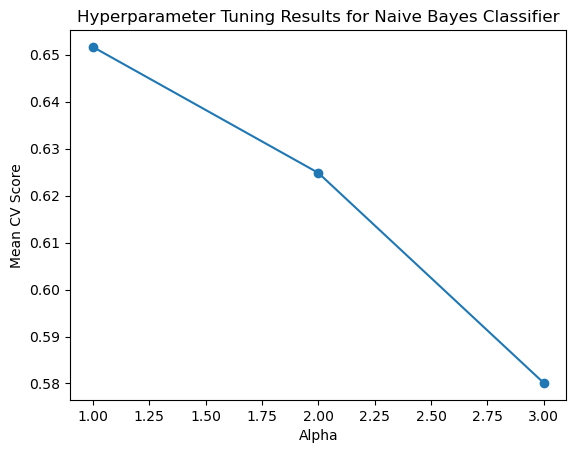

In [44]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_nb.cv_results_)
plt.figure()
plt.plot(results_df['param_alpha'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Naive Bayes Classifier")
plt.xlabel("Alpha")
plt.ylabel("Mean CV Score")
plt.show()

In [45]:
nb_classifier_multi = CategoricalNB(min_categories = 2, alpha = search_nb.best_params_['alpha'])
start_time = time.time()
nb_classifier_multi.fit(X_train_cat_transformed.toarray(), quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
quality_pred_nb = nb_classifier_multi.predict(X_test_cat_transformed.toarray())
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(nb_classifier_multi.score(X_test_cat_transformed.toarray(), quality_test))
nb_accuracy_multi = 1 - (np.sum(np.where(quality_pred_nb != quality_test, 1, 0)) / np.size(quality_test))
print(nb_accuracy_multi)

Training took 0.0030 seconds
Testing took 0.0002 seconds
0.7368421052631579
0.736842105263158


In [46]:
# Fit an artificial nerual network with tuned numbers of hidden layer nodes, max iterations, and an activation function selected using 5-fold cross validation
search_ann = GridSearchCV(MLPClassifier(), ann_param_grid, cv=5)
search_ann.fit(X_train_transformed, quality_train)

GridSearchCV(cv=5, estimator=MLPClassifier(),
             param_grid={'activation': ['logistic', 'tanh', 'relu'],
                         'hidden_layer_sizes': [(5,), (10,), (20,), (50,),
                                                (100,), (150,)],
                         'max_iter': [2000, 5000, 10000, 20000]})

<Figure size 640x480 with 0 Axes>

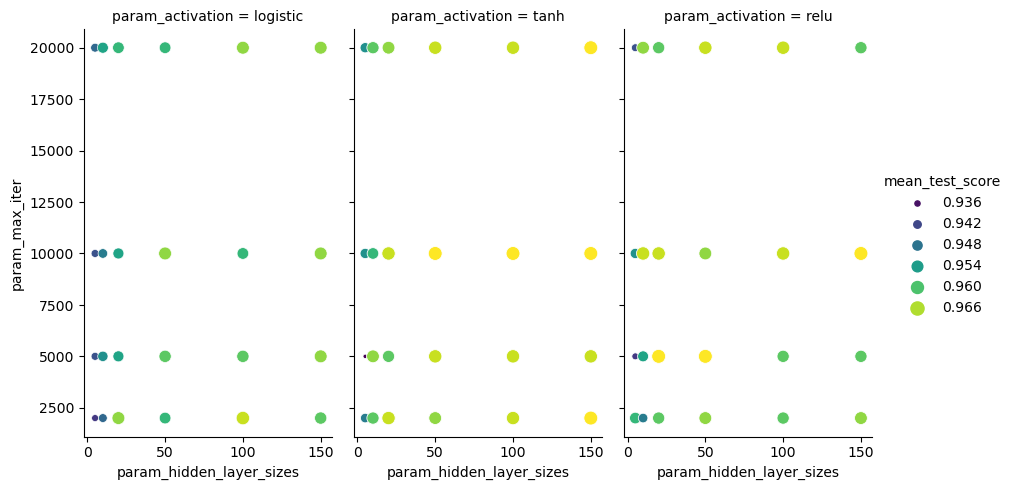

In [47]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_ann.cv_results_)
results_df['param_hidden_layer_sizes'] = results_df['param_hidden_layer_sizes'].str[0].astype(int)
plt.figure()
sns.relplot(data=results_df, x="param_hidden_layer_sizes", y="param_max_iter", hue="mean_test_score", col="param_activation", palette="viridis", kind="scatter", size="mean_test_score", sizes=(10,100), aspect=0.6)
plt.show()

In [48]:
ann_classifier_multi = MLPClassifier(hidden_layer_sizes = search_ann.best_params_['hidden_layer_sizes'], max_iter = search_ann.best_params_['max_iter'], activation = search_ann.best_params_['activation'])
start_time = time.time()
ann_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")

start_time = time.time()
quality_pred_ann = ann_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(ann_classifier_multi.score(X_test_transformed, quality_test))
ann_accuracy_multi = 1 - (np.sum(np.where(quality_pred_ann != quality_test, 1, 0)) / np.size(quality_test))
print(ann_accuracy_multi)

Training took 0.1617 seconds
Testing took 0.0003 seconds
0.9473684210526315
0.9473684210526316
